In [2]:
import numpy as np
import h5py
import time

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from dataset_generation.gw_class_gen import *
from config import *

import warnings
warnings.filterwarnings("ignore")

In [72]:
def make_tdi_dict(X, Y, Z, whiten=True):
    A, E, T = get_AET(X, Y, Z)

    tdi_dict = {}
    channel_names = ['X', 'Y', 'Z', 'A', 'E', 'T']
    channel_data = [X, Y, Z, A, E, T]
    for i, name in enumerate(channel_names):
        if whiten:
            psd_data = np.load(PSD_PATH / f'psd_{name}.npz')
            f_psd, psd = psd_data['f_psd'], psd_data['psd']
            tdi_dict[name] = whiten_with_psd(channel_data[i], dt=0.25, f_psd=f_psd, psd=psd, alpha=0.1)
        else:
            tdi_dict[name] = channel_data[i]
    return tdi_dict

In [206]:
pipe = {'t0':10368000, 'dt':0.25, 'size':10*3600/0.25}

glitches = [{'type':'ShapeletGlitch', 't_inj': 4.1*3600, 'beta':3.37e3,
             'level':2e-6, 'inj_point':'tm_21'}]
#glitches = [{'type':'OneSidedDoubleExpGlitch', 't_inj': 0,
            # 'level':0, 't_rise':1, 't_fall':1, 'inj_point':'tm_23'}]

gws = [{'type':'ReducedOneSidedDoubleExpGW', 't_inj': 0, 'amp':0, 't_rise':1, 't_fall':1,
        'gw_beta':0.02*np.pi, 'gw_lambda':0.98*np.pi}]
gws = [{'type': 'BinaryInspiralGW', 'm1': 4e6, 'm2': 2e7, 'd': 3e3,
        'spin1': 0.42, 'spin2': -0.42, 't_inj': 5.9*3600, 'domain': 'freq', 'gw_beta':0.09*np.pi, 'gw_lambda':1.09*np.pi}]

In [207]:
run_simulation(gws, glitches, pipe,
                gw_path, glitch_path, orbits_path, simulation_path, disable_noise=False)
raw_dict = run_tdi(simulation_path, pipe)

You are using an orbit file in a version that might not be fully supported
You are using an orbit file in a version that might not be fully supported
You are using a glitch file in a version that might not be fully supported


In [208]:
specs = {'low_mass': {'trange':(-2, 2), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(29, 31, 5), 'Q':30,
                      'drange':np.logspace(3, 4, 5)},
         'high_mass': {'trange':(-4, 1), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(15, 17, 5), 'Q':16,
                      'drange':np.logspace(3, 5, 5)},
         'ext_high_mass': {'trange':(-4, 2), 'frange':(1e-4, 1e-2), 
                       'Qvals':np.linspace(5, 7, 5), 'Q':10,
                       'drange':np.logspace(4, 5, 5)}}

In [209]:
event = gws[0]
channel = 'A'
res = 256
spec = specs['ext_high_mass']
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)

start = time.time()
t_arr, f_arr, varQT = varq_transform(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Qvals=spec['Qvals'])
t_arr2, f_arr2, QT = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Q=spec['Q'])
end = time.time()
print(end - start)

1.0947048664093018


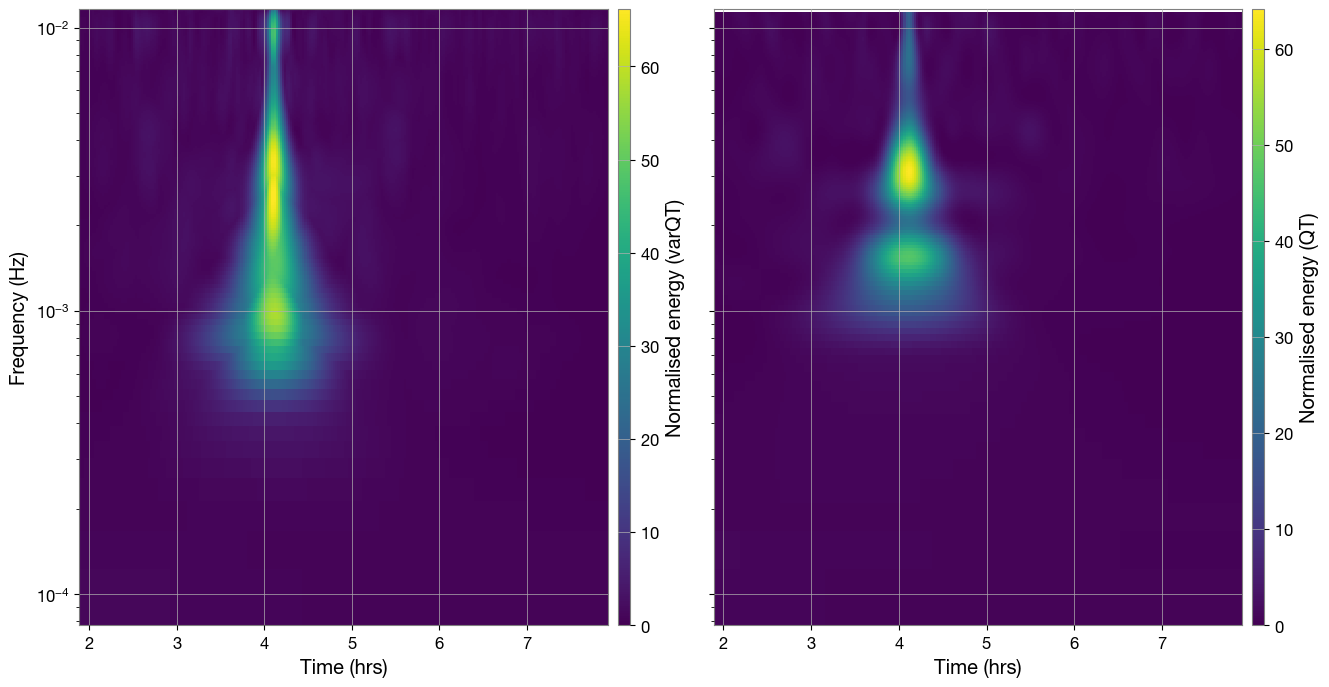

In [210]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(15,8))
#title = f'level={event["level"]:.2e}, beta={event["beta"]:.2e}, inj_point={event["inj_point"]}'
#fig.suptitle(title, fontsize=16)

axes[0].pcolormesh(t_arr/3600, f_arr, varQT, cmap='viridis')
axes[1].pcolormesh(t_arr2/3600, f_arr2, QT, cmap='viridis')
axes[0].set_xlabel('Time (hrs)')
axes[1].set_xlabel('Time (hrs)')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[0].colorbar(label='Normalised energy (varQT)')
axes[1].colorbar(label='Normalised energy (QT)')
plt.show()